
Running: Imp1 — Larger LSTM (hidden=64)
Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.1055 - val_loss: 0.0978
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0800 - val_loss: 0.1003
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0653 - val_loss: 0.1154
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0514 - val_loss: 0.1281
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.0415 - val_loss: 0.1366
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0334 - val_loss: 0.1479
Imp1 — Larger LSTM (hidden=64) — Best Val MSE: 0.0978 | Epochs: 6

Running: Imp2 — Stacked LSTM (2 layers)
Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.1089 - val_loss: 0.1012
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - loss: 0.0815 - val_loss: 0.1063
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - loss: 0.0686 - val_loss: 0.1182
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 

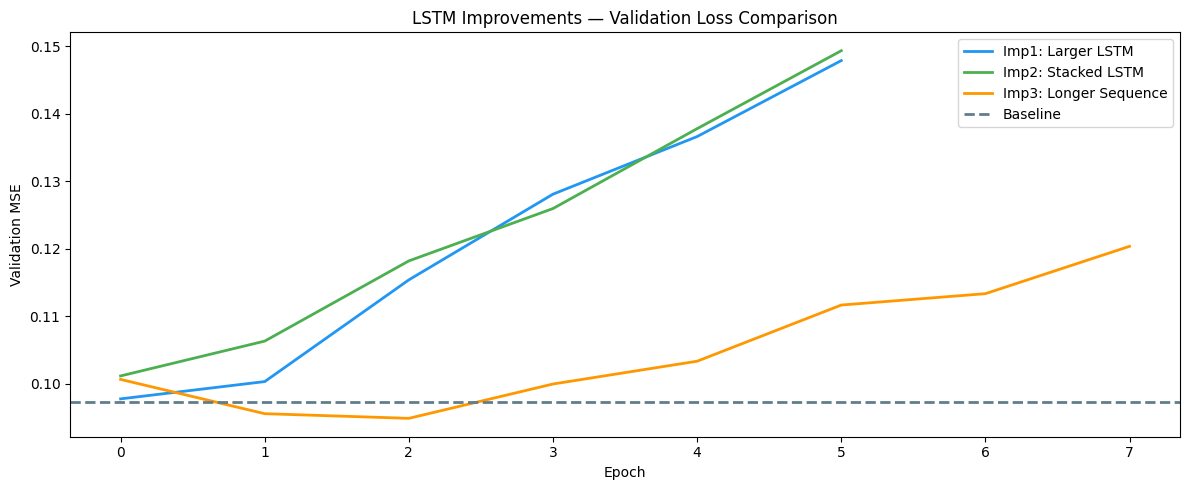

Done!


In [ ]:
# ---- LSTM Improvements — All 3 in one cell ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request, zipfile, os
import tensorflow as tf
from tensorflow import keras

# Load dataset
csv_path = '/tmp/jena_climate_2009_2016.csv'
if not os.path.exists(csv_path):
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
        '/tmp/jena.zip'
    )
    with zipfile.ZipFile('/tmp/jena.zip') as z:
        z.extractall('/tmp/')

df = pd.read_csv(csv_path)
feature_keys = ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
                'rh (%)', 'VPmax (mbar)', 'VPact (mbar)']
features = df[feature_keys].replace(-9999.0, 0)
train_split = int(len(features) * 0.715)

def normalize(data, split):
    mean = data[:split].mean(axis=0)
    std  = data[:split].std(axis=0)
    return (data - mean) / std

features = normalize(features.values, train_split)

def make_datasets(past=720, future=72, step=6, batch=256):
    train_data = features[:train_split]
    val_data   = features[train_split:]
    train_targets = features[past + future : train_split + past + future, 1]
    val_targets   = features[train_split + past + future :, 1]
    x_train = keras.utils.timeseries_dataset_from_array(
        train_data, targets=train_targets,
        sequence_length=past // step, sampling_rate=step,
        batch_size=batch, shuffle=True, seed=42)
    x_val = keras.utils.timeseries_dataset_from_array(
        val_data, targets=val_targets,
        sequence_length=past // step, sampling_rate=step,
        batch_size=batch, shuffle=False)
    return x_train, x_val

def build_lstm(hidden=32, stacked=False):
    inputs = keras.Input(shape=(120, 7))
    if stacked:
        x = keras.layers.LSTM(hidden, return_sequences=True)(inputs)
        x = keras.layers.LSTM(hidden)(x)
    else:
        x = keras.layers.LSTM(hidden)(inputs)
    outputs = keras.layers.Dense(1)(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

def run_experiment(label, hidden=32, stacked=False, past=720):
    print(f'\nRunning: {label}')
    x_train, x_val = make_datasets(past=past)
    model = build_lstm(hidden=hidden, stacked=stacked)
    callbacks = [
        keras.callbacks.ModelCheckpoint(f'/tmp/{label}.weights.h5',
            monitor='val_loss', save_best_only=True, save_weights_only=True),
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
            restore_best_weights=True)
    ]
    history = model.fit(x_train, epochs=10, validation_data=x_val,
                        callbacks=callbacks, verbose=1)
    best_val = min(history.history['val_loss'])
    epochs_run = len(history.history['loss'])
    print(f'{label} — Best Val MSE: {best_val:.4f} | Epochs: {epochs_run}')
    return {'Experiment': label, 'Best Val MSE': round(best_val, 4),
            'Epochs': epochs_run, 'history': history}

# Baseline reference
baseline_result = {'Experiment': 'Baseline (hidden=32, 1 layer, look-back=5d)',
                   'Best Val MSE': 0.0973, 'Epochs': 10}

# Run 3 improvements
imp1 = run_experiment('Imp1 — Larger LSTM (hidden=64)', hidden=64)
imp2 = run_experiment('Imp2 — Stacked LSTM (2 layers)', hidden=32, stacked=True)
imp3 = run_experiment('Imp3 — Longer Sequence (10 days)', hidden=32, past=1440)

# Results table
results = [baseline_result,
           {k: v for k, v in imp1.items() if k != 'history'},
           {k: v for k, v in imp2.items() if k != 'history'},
           {k: v for k, v in imp3.items() if k != 'history'}]
df_results = pd.DataFrame(results)
print('\n===== IMPROVEMENT RESULTS =====')
print(df_results.to_string(index=False))

# Plot val loss curves
plt.figure(figsize=(12, 5))
plt.plot(imp1['history'].history['val_loss'], label='Imp1: Larger LSTM', color='#2196F3', linewidth=2)
plt.plot(imp2['history'].history['val_loss'], label='Imp2: Stacked LSTM', color='#4CAF50', linewidth=2)
plt.plot(imp3['history'].history['val_loss'], label='Imp3: Longer Sequence', color='#FF9800', linewidth=2)
plt.axhline(y=0.0973, color='#607D8B', linestyle='--', linewidth=2, label='Baseline')
plt.xlabel('Epoch')
plt.ylabel('Validation MSE')
plt.title('LSTM Improvements — Validation Loss Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_improvements.png', dpi=120, bbox_inches='tight')
plt.show()
print('Done!')